## This is the code to generate the lift for class imbalance experiment

By default, if you play this file directly, it will generate the Lift plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists -> Compute the percentage of minority group appears in top-k -> Compute the Lift for each K and ratio -> Plot the Lift

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The Lift Plot 

You don't need to change anything else if you only want to produce the Lift plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [49]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

# Read-In Area

Change the following filename if you want to test on other estimation results.

In [50]:
IF_9_1 = pd.read_csv("ClassImbalance/IF_9_1_class.csv")
IF_8_2 = pd.read_csv("ClassImbalance/IF_8_2_class.csv")
IF_7_3 = pd.read_csv("ClassImbalance/IF_7_3_class.csv")
IF_6_4 = pd.read_csv("ClassImbalance/IF_6_4_class.csv")
IF_5_5 = pd.read_csv("ClassImbalance/IF_5_5_class.csv")


TC_9_1 = pd.read_csv("ClassImbalance/TC_9_1_class.csv")
TC_8_2 = pd.read_csv("ClassImbalance/TC_8_2_class.csv")
TC_7_3 = pd.read_csv("ClassImbalance/TC_7_3_class.csv")
TC_6_4 = pd.read_csv("ClassImbalance/TC_6_4_class.csv")
TC_5_5 = pd.read_csv("ClassImbalance/TC_5_5_class.csv")

Label_1 = pd.read_csv("ClassImbalance/9_1_class_labelIDs.csv")
Label_2 = pd.read_csv("ClassImbalance/8_2_class_labelIDs.csv")
Label_3 = pd.read_csv("ClassImbalance/7_3_class_labelIDs.csv")
Label_4 = pd.read_csv("ClassImbalance/6_4_class_labelIDs.csv")
Label_5 = pd.read_csv("ClassImbalance/5_5_class_labelIDs.csv")


# Analyze Area

1. We store all the information we need in lists here.

In [51]:
sorted_IF_lists = [IF_9_1, IF_8_2,IF_7_3,IF_6_4,IF_5_5]
sorted_TC_lists = [TC_9_1, TC_8_2,TC_7_3,TC_6_4,TC_5_5]
ratio=[(9,1),(8,2),(7,3),(6,4),(5,5)]
sorted_label_lists = [Label_1,Label_2,Label_3,Label_4,Label_5]
num_lists = len(sorted_IF_lists)
random_selection_rate = [0.1, 0.2, 0.3, 0.4, 0.5]

In [52]:
K = 200

In [53]:
def compute_sign_aware_lift(
    influence_df,
    label_df,
    minority_rate,
    k=100,
    score_col="Score"
):
    """
    Compute minority lift in:
      1. top-k signed influence scores,
      2. bottom-k signed influence scores,
      3. top-k absolute influence scores.

    Lift = minority proportion in selected set
           -----------------------------------
           minority proportion in full training set
    """

    ranked = influence_df.merge(
        label_df,
        left_on="Train_ID",
        right_on="id",
        how="left",
        validate="one_to_one"
    )

    ranked = ranked.drop(columns=["id"])

    if ranked["label"].isna().any():
        missing = ranked["label"].isna().sum()
        raise ValueError(f"{missing} influence rows have no matching label.")

    if score_col not in ranked.columns:
        raise KeyError(
            f"Cannot find score column '{score_col}'. "
            f"Available columns: {ranked.columns.tolist()}"
        )

    if k > len(ranked):
        raise ValueError(
            f"k={k} exceeds the number of training samples ({len(ranked)})."
        )

    # Highest signed influence
    top_signed = ranked.nlargest(k, score_col)

    # Lowest, most negative signed influence
    bottom_signed = ranked.nsmallest(k, score_col)

    # Largest influence magnitude
    top_absolute = (
        ranked.assign(Abs_Score=ranked[score_col].abs())
        .nlargest(k, "Abs_Score")
    )

    top_rate = top_signed["label"].mean()
    bottom_rate = bottom_signed["label"].mean()
    abs_top_rate = top_absolute["label"].mean()

    return {
        "Lift@Top": top_rate / minority_rate,
        "Lift@Bottom": bottom_rate / minority_rate,
        "Lift@AbsTop": abs_top_rate / minority_rate,
        "Minority@Top": top_rate,
        "Minority@Bottom": bottom_rate,
        "Minority@AbsTop": abs_top_rate
    }

In [54]:
records = []

for i in range(num_lists):
    minority_rate = float(random_selection_rate[i])

    # FOIF
    if_result = compute_sign_aware_lift(
        influence_df=sorted_IF_lists[i],
        label_df=sorted_label_lists[i],
        minority_rate=minority_rate,
        k=K,
        score_col="Score"
    )

    records.append({
        "Dataset": r"SYN_A",
        "Method": "FOIF",
        "Ratio": f"{ratio[i][1]}:{ratio[i][0]}",
        "k": K,
        "Lift@Top": if_result["Lift@Top"],
        "Lift@Bottom": if_result["Lift@Bottom"],
        "Lift@AbsTop": if_result["Lift@AbsTop"]
    })

    # TracIn
    tc_result = compute_sign_aware_lift(
        influence_df=sorted_TC_lists[i],
        label_df=sorted_label_lists[i],
        minority_rate=minority_rate,
        k=K,
        score_col="Score"
    )

    records.append({
        "Dataset": r"SYN_A",
        "Method": "TracIn",
        "Ratio": f"{ratio[i][1]}:{ratio[i][0]}",
        "k": K,
        "Lift@Top": tc_result["Lift@Top"],
        "Lift@Bottom": tc_result["Lift@Bottom"],
        "Lift@AbsTop": tc_result["Lift@AbsTop"]
    })

sign_aware_lift_table = pd.DataFrame(records)

print(sign_aware_lift_table.round(3))

  Dataset  Method Ratio    k  Lift@Top  Lift@Bottom  Lift@AbsTop
0   SYN_A    FOIF   1:9  200    10.000        1.450        7.300
1   SYN_A  TracIn   1:9  200    10.000        0.000        5.900
2   SYN_A    FOIF   2:8  200     5.000        1.600        2.525
3   SYN_A  TracIn   2:8  200     5.000        0.000        2.425
4   SYN_A    FOIF   3:7  200     3.333        1.267        1.533
5   SYN_A  TracIn   3:7  200     3.333        0.000        1.083
6   SYN_A    FOIF   4:6  200     2.462        1.162        1.187
7   SYN_A  TracIn   4:6  200     2.500        0.900        1.037
8   SYN_A    FOIF   5:5  200     0.900        0.860        0.930
9   SYN_A  TracIn   5:5  200     2.000        0.000        0.580


In [55]:
table_1_9 = sign_aware_lift_table[
    sign_aware_lift_table["Ratio"] == "1:9"
].copy()

table_1_9 = table_1_9[
    [
        "Dataset",
        "Method",
        "Ratio",
        "Lift@Top",
        "Lift@Bottom",
        "Lift@AbsTop"
    ]
]

print(table_1_9.round(3))

  Dataset  Method Ratio  Lift@Top  Lift@Bottom  Lift@AbsTop
0   SYN_A    FOIF   1:9      10.0         1.45          7.3
1   SYN_A  TracIn   1:9      10.0         0.00          5.9


2. Since we always have label 1 as the minority group, here we check how many 1 appears in top-k. Then, we compute the lift based on that with the random_selection_rate.

In [56]:
for i in range(num_lists):
    ranked = (sorted_TC_lists[i]
              .merge(sorted_label_lists[i], left_on="Train_ID", right_on="id", how="left"))
    ranked = ranked.drop(columns=["id"])

    p_random = float(random_selection_rate[i])  # your precomputed random % for this ratio/run

    Ks = [k for k in [10, 20, 50, 100, 200, 400, 800, 1600, 3200] if 1 <= k <= len(ranked)]

    topk_rates = [ranked["label"].head(k).mean() for k in Ks]
    topk_tbl = pd.DataFrame({
        "k": Ks,
        "%1s_topk": topk_rates,
    })

    topk_tbl["lift@k"] = topk_tbl["%1s_topk"] / p_random

    topk_tbl["gain@k"] = topk_tbl["%1s_topk"] - p_random

    print(f"Run {i+1}  Ratio: {ratio[i]}  (random p={p_random:.4f})  top-k results:")
    print(topk_tbl)

Run 1  Ratio: (9, 1)  (random p=0.1000)  top-k results:
      k  %1s_topk    lift@k    gain@k
0    10  1.000000  10.00000  0.900000
1    20  1.000000  10.00000  0.900000
2    50  1.000000  10.00000  0.900000
3   100  1.000000  10.00000  0.900000
4   200  1.000000  10.00000  0.900000
5   400  1.000000  10.00000  0.900000
6   800  0.687500   6.87500  0.587500
7  1600  0.343750   3.43750  0.243750
8  3200  0.171875   1.71875  0.071875
Run 2  Ratio: (8, 2)  (random p=0.2000)  top-k results:
      k  %1s_topk    lift@k    gain@k
0    10  1.000000  5.000000  0.800000
1    20  1.000000  5.000000  0.800000
2    50  1.000000  5.000000  0.800000
3   100  1.000000  5.000000  0.800000
4   200  1.000000  5.000000  0.800000
5   400  1.000000  5.000000  0.800000
6   800  1.000000  5.000000  0.800000
7  1600  0.843750  4.218750  0.643750
8  3200  0.421875  2.109375  0.221875
Run 3  Ratio: (7, 3)  (random p=0.3000)  top-k results:
      k  %1s_topk    lift@k    gain@k
0    10  1.000000  3.333333  0.700

3. Then, we group the lift based on the ratio and k for furthering ploting the graph.

In [57]:
records = [] 

for i in range(num_lists):
    ranked = (sorted_TC_lists[i]
              .merge(sorted_label_lists[i], left_on="Train_ID", right_on="id", how="left"))
    ranked = ranked.drop(columns=["id"])

    p_random = float(random_selection_rate[i])   

    Ks = [k for k in [10, 20, 50, 100, 200, 400, 800, 1600, 3200] if 1 <= k <= len(ranked)]
    topk_rates = [ranked["label"].head(k).mean() for k in Ks]
    lifts = [(r / p_random) if p_random > 0 else np.nan for r in topk_rates]

    for k, lift in zip(Ks, lifts):
        records.append({"ratio": ratio[i], "k": k, "lift": lift})

all_tbl = pd.DataFrame(records)

In [58]:
print(all_tbl)

     ratio     k       lift
0   (9, 1)    10  10.000000
1   (9, 1)    20  10.000000
2   (9, 1)    50  10.000000
3   (9, 1)   100  10.000000
4   (9, 1)   200  10.000000
5   (9, 1)   400  10.000000
6   (9, 1)   800   6.875000
7   (9, 1)  1600   3.437500
8   (9, 1)  3200   1.718750
9   (8, 2)    10   5.000000
10  (8, 2)    20   5.000000
11  (8, 2)    50   5.000000
12  (8, 2)   100   5.000000
13  (8, 2)   200   5.000000
14  (8, 2)   400   5.000000
15  (8, 2)   800   5.000000
16  (8, 2)  1600   4.218750
17  (8, 2)  3200   2.109375
18  (7, 3)    10   3.333333
19  (7, 3)    20   3.333333
20  (7, 3)    50   3.333333
21  (7, 3)   100   3.333333
22  (7, 3)   200   3.333333
23  (7, 3)   400   3.333333
24  (7, 3)   800   3.333333
25  (7, 3)  1600   3.333333
26  (7, 3)  3200   2.239583
27  (6, 4)    10   2.500000
28  (6, 4)    20   2.500000
29  (6, 4)    50   2.500000
30  (6, 4)   100   2.500000
31  (6, 4)   200   2.500000
32  (6, 4)   400   2.487500
33  (6, 4)   800   2.462500
34  (6, 4)  1600   2

Then, we shall obtain for each ratio and each k, what is the lift of that.

In [59]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
all_tbl["ratio"] = pd.Categorical(all_tbl["ratio"], categories=ratio, ordered=True)

pivot_kx = all_tbl.pivot_table(index="k", columns="ratio", values="lift", aggfunc="mean")
pivot_rx = all_tbl.pivot_table(index="ratio", columns="k", values="lift", aggfunc="mean")
print(pivot_kx)

ratio    (9, 1)    (8, 2)    (7, 3)    (6, 4)  (5, 5)
k                                                    
10     10.00000  5.000000  3.333333  2.500000     2.0
20     10.00000  5.000000  3.333333  2.500000     2.0
50     10.00000  5.000000  3.333333  2.500000     2.0
100    10.00000  5.000000  3.333333  2.500000     2.0
200    10.00000  5.000000  3.333333  2.500000     2.0
400    10.00000  5.000000  3.333333  2.487500     2.0
800     6.87500  5.000000  3.333333  2.462500     2.0
1600    3.43750  4.218750  3.333333  2.279687     2.0
3200    1.71875  2.109375  2.239583  1.618750     2.0


# Plot Area

Plot 1: x axis is k, bars are ratio

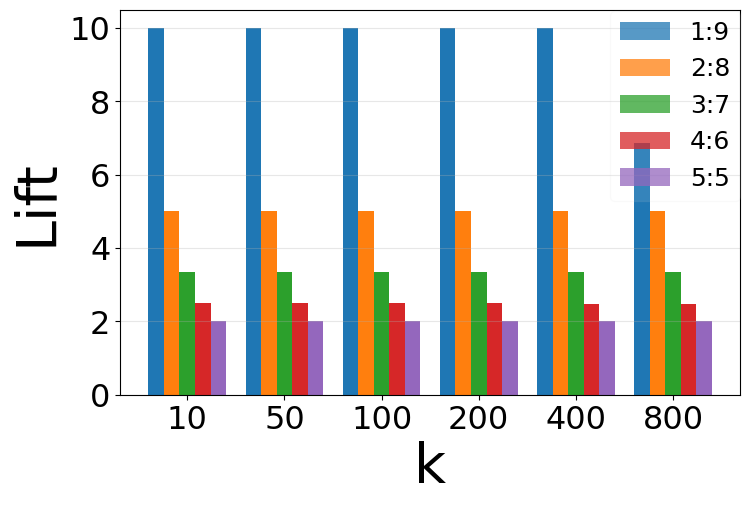

In [60]:
selected_K = [10, 50, 100, 200, 400, 800]

plot_df = pivot_kx.loc[selected_K]

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(plot_df.index))
n_groups = len(plot_df.columns)
bar_width = 0.8 / n_groups

for j, col in enumerate(plot_df.columns):
    ax.bar(
        x + j * bar_width - 0.4 + bar_width / 2,
        plot_df[col].values,
        width=bar_width,
        label=f"{col[1]}:{col[0]}" if isinstance(col, tuple) else str(col)
    )

ax.set_xlabel("k", fontsize=40)
ax.set_ylabel("Lift", fontsize=40)

# remove title
# ax.set_title(...)

ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in plot_df.index], fontsize=23)
ax.tick_params(axis="y", labelsize=23)

legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.02, 1.03),
    fontsize=18,
    framealpha=0.1
)

for h in legend.legend_handles:
    h.set_alpha(0.75)
    
ax.grid(axis="y", alpha=0.3)
#plt.tight_layout()

plt.savefig(
    "Class_Imbalance_Synthetic_TC.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()